# Advanced Active Learning with Multiple Annotators

> **_Google Colab Note:_** If the notebook fails to run after installing the needed packages, try to restart the runtime (Ctrl + M) under Runtime -> Restart session.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](<colab_link>)

**Notebook Dependencies**

Uncomment the following cell to install all dependencies for this tutorial.

In [9]:
# !pip install scikit-activeml skorch torch tqdm

<hr style="border-style: solid; border-top: 1px solid; border-right: 0; border-bottom: 0; border-left: 0;">

This notebook demonstrates how to use `scikit-activeml` to perform pool-based active learning when labels are provided by multiple, potentially unreliable annotators. We work on the handwritten digits dataset and simulate a small crowd of annotators with different noise patterns. We then compare a simple majority-vote baseline with a dedicated multi-annotator model that learns annotator performance (i.e., annotation accuracy) while querying new labels.

In [10]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

from skactiveml.classifier import SkorchClassifier
from skactiveml.classifier.multiannotator import AnnotMixClassifier
from skactiveml.pool import RandomSampling
from skactiveml.pool.multiannotator import SingleAnnotatorWrapper
from skactiveml.utils import MISSING_LABEL, is_labeled, majority_vote

from skorch.callbacks import LRScheduler
from torch import nn
from torch.optim import RAdam
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm.auto import tqdm


# Global configuration
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)
warnings.filterwarnings("ignore")

## Data Preparation and Simulation of Multiple Annotators

We start by loading the digits dataset and splitting it into training and test sets. Each image is scaled to the range \([0, 1]\) and reshaped to match the input format expected by a small convolutional neural network. On top of the ground-truth training labels `y_train` we simulate five annotators with different reliability profiles:

- some are almost perfect,
- some are noisy, one struggles with a specific digit,
- and another one is biased towards the majority class.

The resulting matrix `z_train` has one column per annotator and serves as crowd labels for the multi-annotator models.


In [11]:
# Load and preprocess the data
digits = load_digits()
X = digits.images[:, np.newaxis, :, :] / 16.0  # (n_samples, 1, 8, 8)
y = digits.target
classes = np.unique(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.5,
    stratify=y,
    random_state=42,
)

rng = np.random.default_rng(0)
n_samples = len(y_train)
classes = np.asarray(classes)
y_train = np.asarray(y_train)


def sample_noisy_labels(y_true, accuracy, rng):
    """Generate annotator labels with a given accuracy.

    With probability `accuracy` the annotator returns
    the true label. Otherwise, it samples a wrong label
    uniformly from the remaining classes.
    """
    y_true = np.asarray(y_true)
    n = y_true.shape[0]
    y_annot = y_true.copy()

    correct = rng.random(n) < accuracy
    wrong_idx = np.flatnonzero(~correct)

    if wrong_idx.size:
        wrong_labels = []
        for yt in y_true[wrong_idx]:
            candidates = classes[classes != yt]
            wrong_labels.append(rng.choice(candidates))
        y_annot[wrong_idx] = wrong_labels

    return y_annot


# Annotator 1: almost perfect
ann1 = sample_noisy_labels(y_train, accuracy=0.95, rng=rng)

# Annotator 2: strong, but clearly imperfect
ann2 = sample_noisy_labels(y_train, accuracy=0.85, rng=rng)

# Annotator 3: noticeably noisy
ann3 = sample_noisy_labels(y_train, accuracy=0.70, rng=rng)

# Annotator 4: class-dependent difficulties
# (struggles with one hard digit)
hard_class = 9  # treat digit '9' as hard, for example
acc_easy = 0.85
acc_hard = 0.40

per_sample_acc = np.where(y_train == hard_class, acc_hard, acc_easy)
rand = rng.random(n_samples)
correct = rand < per_sample_acc

ann4 = y_train.copy()
wrong_idx = np.flatnonzero(~correct)
if wrong_idx.size:
    wrong_labels = []
    for yt in y_train[wrong_idx]:
        candidates = classes[classes != yt]
        wrong_labels.append(rng.choice(candidates))
    ann4[wrong_idx] = wrong_labels

# Annotator 5: biased towards the majority class
values, counts = np.unique(y_train, return_counts=True)
majority_class = values[counts.argmax()]

ann5 = y_train.copy()
bias_strength = 0.50  # probability of forcing the majority label
bias_mask = rng.random(n_samples) < bias_strength
ann5[bias_mask] = majority_class

# Final annotation matrix: shape (n_samples, n_annotators)
z_train = np.column_stack([ann1, ann2, ann3, ann4, ann5])
n_annotators = z_train.shape[1]

## Neural Network Backbone and Classifiers

The next step is to define a small convolutional network (CNN) that serves as a backbone for all classifiers. The network processes the 8 x 8 images, applies a single convolutional layer with max pooling, and maps the resulting 128-dimensional feature vector to class logits. The forward method returns both the logits and the intermediate embedding, which could be used by an active learning query strategy, such as `BADGE`.

On top of this backbone we define two classifiers.

- The `MajorityVoteClassifier` first aggregates the crowd labels in `z_train` by taking a majority vote per sample and then fits a standard single-annotator model.
- In contrast, `AnnotMixClassifier` directly consumes the full matrix of annotator labels and internally models annotator performance.

Both models share the same neural architecture and optimization hyperparameters so that differences in performance can be attributed to how they handle multiple annotators.


In [12]:
# Small CNN backbone for 8×8 digit images
class ClassificationModule(nn.Module):
    """
    Compact CNN that returns both logits
    and a 128-dimensional embedding.
    """

    def __init__(self, n_classes=10):
        super().__init__()

        # Input: (B, 1, 8, 8)
        self.conv = nn.Conv2d(
            in_channels=1,
            out_channels=8,
            kernel_size=3,
            padding=1,
        )  # -> (B, 8, 8, 8)

        self.feature_dim = 8 * 4 * 4  # after 2×2 pooling: (B, 8, 4, 4)
        self.fc = nn.Linear(self.feature_dim, n_classes)

    def forward(self, x: torch.Tensor):
        # x: (B, 1, 8, 8)
        x = self.conv(x)
        x = F.relu(x)
        x = F.max_pool2d(x, kernel_size=2)  # (B, 8, 4, 4)
        x_embed = x.view(x.size(0), -1)  # (B, 128)
        logits = self.fc(x_embed)  # (B, n_classes)
        return logits, x_embed


EMBED_DIM = 8 * 4 * 4  # must match ClassificationModule.feature_dim


class MajorityVoteClassifier(SkorchClassifier):
    """
    Classifier that trains on labels
    aggregated by majority vote.
    """

    def fit(self, X, y, **fit_params):
        y_mv = majority_vote(
            y,
            classes=self.classes,
            missing_label=self.missing_label,
            random_state=self.random_state,
        )
        return super().fit(X, y_mv, **fit_params)


MAX_EPOCHS = 100

# Parameters passed to the NeuralNet in skorch`
neural_net_param_dict = {
    # Module-related parameters.
    "module__n_classes": len(classes),
    # Optimizer-related parameters.
    "max_epochs": MAX_EPOCHS,
    "optimizer": RAdam,
    "optimizer__weight_decay": 0.001,
    "optimizer__lr": 0.01,
    # Data loading parameters.
    "iterator_train__shuffle": True,
    "iterator_train__num_workers": 1,
    "iterator_train__batch_size": 16,
    "iterator_valid__batch_size": 64,
    "iterator_train__drop_last": True,
    "train_split": None,
    # Scheduler.
    "callbacks": [
        (
            "lr_scheduler",
            LRScheduler(policy=CosineAnnealingLR, T_max=MAX_EPOCHS),
        ),
    ],
    # Misc.
    "verbose": 0,
    "device": DEVICE,
}

# Common keyword arguments shared by all classifiers
common_clf_kwargs = dict(
    classes=classes,
    missing_label=MISSING_LABEL,
    sample_dtype=np.float32,
    neural_net_param_dict=neural_net_param_dict,
)


def make_majority_vote_classifier(random_state):
    return MajorityVoteClassifier(
        module=ClassificationModule,
        criterion=nn.CrossEntropyLoss,
        predict_nonlinearity=nn.Softmax(dim=-1),
        random_state=random_state,
        **common_clf_kwargs,
    )


def make_annot_mix_classifier(random_state):
    return AnnotMixClassifier(
        clf_module=ClassificationModule,
        clf_sample_embed_dim=EMBED_DIM,
        n_annotators=n_annotators,
        random_state=random_state,
        **common_clf_kwargs,
    )


classifier_dict = {
    "Majority-Vote": make_majority_vote_classifier,
    "Annot-Mix": make_annot_mix_classifier,
}

## Active Learning loop with Multiple Annotators

We now set up the active-learning loop. For each classifier we run several independent repetitions, and in each repetition we start with an annotation matrix `y` that contains only missing labels. We then alternate between fitting the classifier on the currently observed noisy annotations and querying new labels from the simulated annotators.

The query strategy is based on random sampling and wrapped in a `SingleAnnotatorWrapper` so that individual annotator–sample pairs can be requested. For the `Annot-Mix` model we optionally use estimated annotator performances `A_perf` after the first warm-start iteration and pass them to the query strategy. After each cycle we record the test classification accuracy on the held-out test set and the accuracy of the collected labels compared to `y_train`.


In [13]:
n_reps = 3
n_cycles = 10
query_batch_size = 64

results = {}

for clf_name, clf_factory in classifier_dict.items():
    # rows: repetitions, cols: AL cycles (excluding warm start)
    clf_acc = np.full((n_reps, n_cycles), np.nan)
    label_acc = np.full((n_reps, n_cycles), np.nan)

    for i_rep in range(n_reps):
        # Start with all annotations missing
        y = np.full_like(z_train, fill_value=MISSING_LABEL, dtype=np.float32)

        clf = clf_factory(random_state=i_rep)

        base_qs = RandomSampling(
            missing_label=MISSING_LABEL,
            random_state=i_rep,
        )
        ma_qs = SingleAnnotatorWrapper(
            base_qs,
            missing_label=MISSING_LABEL,
            random_state=i_rep,
        )

        for c in tqdm(
            range(n_cycles + 1),
            total=n_cycles + 1,
            desc=f"{clf_name} | repetition {i_rep + 1}/{n_reps}",
        ):
            # Train classifier on current annotations
            clf.fit(X_train, y)

            if c > 0:
                # For Annot-Mix, use estimated annotator performance from the model
                if clf_name == "Annot-Mix":
                    _, A_perf = clf.predict_proba(
                        X_train,
                        return_annotator_perf=True,
                    )
                else:
                    A_perf = None

                # Evaluate label and test accuracy
                is_lbld_y = is_labeled(y, missing_label=MISSING_LABEL)
                n_labels = is_lbld_y.sum()

                if n_labels > 0:
                    is_true_y = y == y_train[:, None]
                    n_correct_labels = (is_true_y & is_lbld_y).sum()
                    label_acc[i_rep, c - 1] = n_correct_labels / n_labels
                    clf_acc[i_rep, c - 1] = clf.score(X_test, y_test)
            else:
                # Warm start: no model-based A_perf
                A_perf = None

            # Query new (sample, annotator) pairs and reveal their labels
            query_idx = ma_qs.query(
                X=X_train,
                y=y,
                batch_size=query_batch_size,
                A_perf=A_perf,
                n_annotators_per_sample=1,
            )
            sample_idx, annotator_idx = query_idx[:, 0], query_idx[:, 1]
            y[sample_idx, annotator_idx] = z_train[sample_idx, annotator_idx]

    results[f"{clf_name}_clf-acc"] = clf_acc
    results[f"{clf_name}_label-acc"] = label_acc

Majority-Vote | repetition 1/3:   0%|          | 0/11 [00:00<?, ?it/s]

Majority-Vote | repetition 2/3:   0%|          | 0/11 [00:00<?, ?it/s]

Majority-Vote | repetition 3/3:   0%|          | 0/11 [00:00<?, ?it/s]

Annot-Mix | repetition 1/3:   0%|          | 0/11 [00:00<?, ?it/s]

Annot-Mix | repetition 2/3:   0%|          | 0/11 [00:00<?, ?it/s]

Annot-Mix | repetition 3/3:   0%|          | 0/11 [00:00<?, ?it/s]

## Visualising Classifier and Annotation Accuracy

To conclude the tutorial we visualise how both classifiers behave as more annotations are acquired. For each method we plot the average test accuracy and the average correct annotation rate across repetitions as a function of the number of acquired annotations. The curves include error bars showing one standard deviation, and the legend reports a simple area-like summary score (ALCU), which is the mean value of each curve over all active-learning cycles. There is one central observations:

> `AnnotMix` is able to model the annotators' performances as basis for increasing the correct annotation rate by greedily assigning annotators with higher performances to samples.


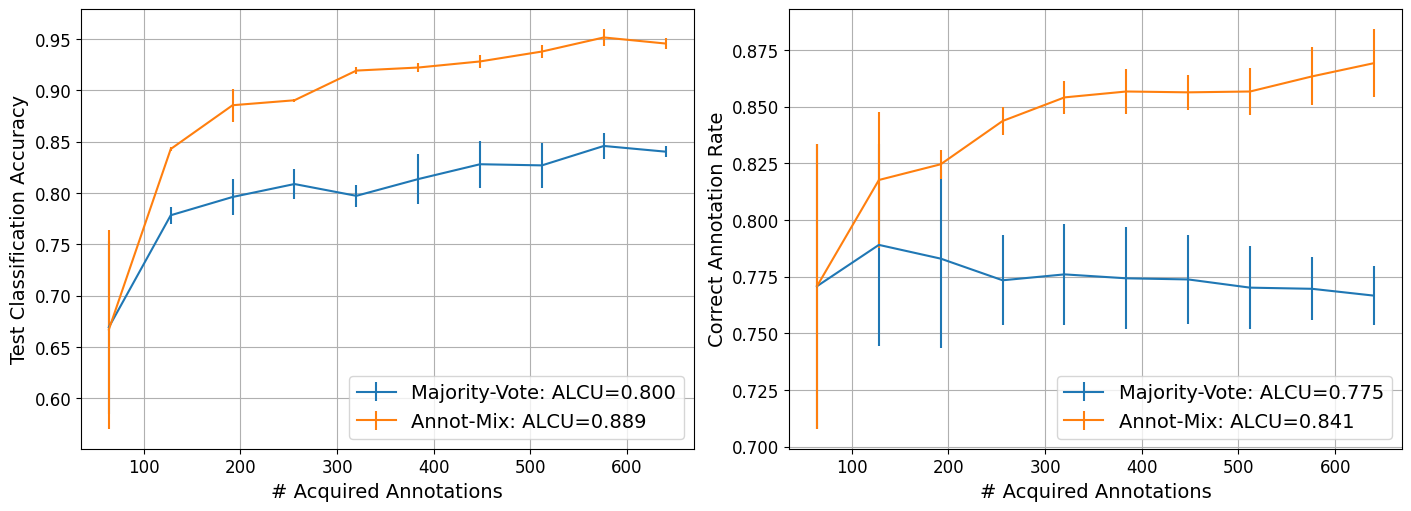

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

metrics = [
    ("clf-acc", "Test Classification Accuracy"),
    ("label-acc", "Correct Annotation Rate"),
]

x_values = np.arange(1, n_cycles + 1) * query_batch_size

for (metric_key, ylabel), ax in zip(metrics, axes):
    for clf_name in classifier_dict.keys():
        result = results[
            f"{clf_name}_{metric_key}"
        ]

        mean_curve = np.mean(result, axis=0)
        std_curve = np.std(result, axis=0)

        alcu = np.mean(mean_curve)

        ax.errorbar(
            x_values,
            mean_curve,
            yerr=std_curve,
            label=f"{clf_name}: ALCU={alcu:.3f}",
            alpha=1.0,
            markersize=0.1,
        )

    ax.set_xlabel("# Acquired Annotations", fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.grid(True)
    ax.legend(
        fontsize=14,
        loc="lower right",
        frameon=True,
    )
    ax.tick_params(axis="both", which="major", labelsize=12)

plt.show()